# IE0005: Intro to Data Science and Artificial Intelligence Mini Project
<i>using "Daily News for Stock Market Prediction" from Kaggle to predict stock prices based on Sentiment Analysis</i>

## Loading the Data
We will only use the "Combined_News_DJIA.csv" and the "upload_DJIA_table.csv" datasets. 

For simplicity, we will say that the "Combined_News_DJIA.csv" as the News table, while the "upload_DJIA_table.csv" as the Price table.

Based on the description:
> From the News table, some important features to use:
- `Date`: The date of the news headline
- `Top1-25`: The top 25 news headlines

> From the Price table, some important features to use:
- `Date`: The date of the stock price
- `Open`: The opening price of stock on each date
- `High`: The highest price of stock on each date
- `Low`: The lowest price of stock on each date
- `Close`: The closing price of stock on each date
- `Adj Close`: The adjusted closing price of the stock (in this case is the same as close)

**Note that in this dataset, value of `Close` is equivalent with `Adj Close`**

In [ ]:
## Importing required libraries (for preprocessing)
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from scipy.special import softmax
import csv
import urllib.request

# Importing required libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.tsa.api as smt
import statsmodels.api as sm



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/kevinjk/opt/anaconda3/envs/tensor/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df_news = pd.read_csv('dataset/Combined_News_DJIA.csv')
df_news[:7]

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Georgia Invades South Ossetia - if Russia ge...,b'Al-Qaeda Faces Islamist Backlash',"b'Condoleezza Rice: ""The US would not act to p...",b'This is a busy day: The European Union has ...,"b""Georgia will withdraw 1,000 soldiers from Ir...",b'Why the Pentagon Thinks Attacking Iran is a ...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge"""
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Israel and the US behind the Georgian aggres...,"b'""Do not believe TV, neither Russian nor Geor...",b'Riots are still going on in Montreal (Canada...,b'China to overtake US as largest manufacturer',b'War in South Ossetia [PICS]',b'Israeli Physicians Group Condemns State Tort...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo..."
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'U.S. troops still in Georgia (did you know t...,b'Why Russias response to Georgia was right',"b'Gorbachev accuses U.S. of making a ""serious ...","b'Russia, Georgia, and NATO: Cold War Two'",b'Remember that adorable 62-year-old who led y...,b'War in Georgia: The Israeli connection',b'All signs point to the US encouraging Georgi...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man..."
3,2008-08-13,0,b' U.S. refuses Israel weapons to attack Iran:...,"b""When the president ordered to attack Tskhinv...",b' Israel clears troops who killed Reuters cam...,b'Britain\'s policy of being tough on drugs is...,b'Body of 14 year old found in trunk; Latest (...,b'China has moved 10 *million* quake survivors...,"b""Bush announces Operation Get All Up In Russi...",b'Russian forces sink Georgian ships ',...,b'Elephants extinct by 2020?',b'US humanitarian missions soon in Georgia - i...,"b""Georgia's DDOS came from US sources""","b'Russian convoy heads into Georgia, violating...",b'Israeli defence minister: US against strike ...,b'Gorbachev: We Had No Choice',b'Witness: Russian forces head towards Tbilisi...,b' Quarter of Russians blame U.S. for conflict...,b'Georgian president says US military will ta...,b'2006: Nobel laureate Aleksander Solzhenitsyn...
4,2008-08-14,1,b'All the experts admit that we should legalis...,b'War in South Osetia - 89 pictures made by a ...,b'Swedish wrestler Ara Abrahamian throws away ...,b'Russia exaggerated the death toll in South O...,b'Missile That Killed 9 Inside Pakistan May Ha...,"b""Rushdie Condemns Random House's Refusal to P...",b'Poland and US agree 

In [ ]:
df_news.shape
print("News Dataset")
print("Number of data: " +  str(df_news.shape[0]) + "\nNumber of features: " + str(df_news.shape[1]))

News Dataset
Number of data: 1989
Number of features: 27


In [ ]:
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1989 non-null   object
 1   Label   1989 non-null   int64 
 2   Top1    1989 non-null   object
 3   Top2    1989 non-null   object
 4   Top3    1989 non-null   object
 5   Top4    1989 non-null   object
 6   Top5    1989 non-null   object
 7   Top6    1989 non-null   object
 8   Top7    1989 non-null   object
 9   Top8    1989 non-null   object
 10  Top9    1989 non-null   object
 11  Top10   1989 non-null   object
 12  Top11   1989 non-null   object
 13  Top12   1989 non-null   object
 14  Top13   1989 non-null   object
 15  Top14   1989 non-null   object
 16  Top15   1989 non-null   object
 17  Top16   1989 non-null   object
 18  Top17   1989 non-null   object
 19  Top18   1989 non-null   object
 20  Top19   1989 non-null   object
 21  Top20   1989 non-null   object
 22  Top21   1989 non-null   

In [ ]:
df_price = pd.read_csv('dataset/upload_DJIA_table.csv')
df_price.head(7)

,Date,Open,High,Low,Close,Volume,Adj Close
0,2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
5,2016-06-24,17946.630859,17946.630859,17356.339844,17400.750000,239000000,17400.750000
6,2016-06-23,17844.109375,18011.070312,17844.109375,18011.070312,98070000,18011.070312


In [ ]:
print("Price Dataset")
print("Number of dataset: " + str(df_price.shape[0]) + "\nNumber of features: " + str(df_price.shape[1]))

Price Dataset
Number of dataset: 1989
Number of features: 7


In [ ]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1989 non-null   object 
 1   Open       1989 non-null   float64
 2   High       1989 non-null   float64
 3   Low        1989 non-null   float64
 4   Close      1989 non-null   float64
 5   Volume     1989 non-null   int64  
 6   Adj Close  1989 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 108.9+ KB


## Preprocessing the Data

For the next step, we will merge both the News table and Price table based on their date

In [ ]:
df_merge = pd.merge(df_news, df_price, on='Date')
df_merge.head()

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top22,Top23,Top24,Top25,Open,High,Low,Close,Volume,Adj Close
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge""",11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo...",11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'All signs point to the US encouraging Georgi...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man...",11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
3,2008-08-13,0,b' U.S. refuses Israel weapons to attack Iran:...,"b""When the president ordered to attack Tskhinv...",b' Israel clears troops who killed Reuters cam...,b'Britain\'s policy of being tough on drugs is...,b'Body of 14 year old found in trunk; Latest (...,b'China has moved 10 *million* quake survivors...,"b""Bush announces Operation Get All Up In Russi...",b'Russian forces sink Georgian ships ',...,b'Witness: Russian forces head towards Tbilisi...,b' Quarter of Russians blame U.S. for conflict...,b'Georgian president says US military will ta...,b'2006: Nobel laureate Aleksander Solzhenitsyn...,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
4,2008-08-14,1,b'All the experts admit that we should legalis...,b'War in South Osetia - 89 pictures made by a ...,b'Swedish wrestler Ara Abrahamian throws away ...,b'Russia exaggerated the death toll in South O...,b'Missile That Killed 9 Inside Pakistan May Ha...,"b""Rushdie Condemns Random House's Refusal to P...",b'Poland and US agree to missle defense deal. ...,"b'Will the Russians conquer Tblisi? Bet on it,...",...,b'Taliban wages war on humanitarian aid workers',"b'Russia: World ""can forget about"" Georgia\'s...",b'Darfur rebels accuse Sudan of mounting major...,b'Philippines : Peace Advocate say Muslims nee...,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688


In [ ]:
df_merge.loc[0, 'Top1']

'b"Georgia \'downs two Russian warplanes\' as countries move to brink of war"'

### Removing Unnecessary Characters

As seen from the above table, one obvious observation that we can see is that the data is not structured. This is because 25 of the features are in the form of string/text, which cannot be easily understand by machine. However, before preprocessing the data, we need to "clean" these texts first as it contains unnecessary characters b' or b", which might be a problem for computer to extract the meaning.

In [ ]:
## Removing 'b' and 'b' from the dataset
df_merge = df_merge.loc[:].apply(lambda d: d.apply(lambda x: x[2:-1] if (type(x)==str and ("b'" in x or 'b"' in x)) else x))
df_merge.head()

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top22,Top23,Top24,Top25,Open,High,Low,Close,Volume,Adj Close
0,2008-08-08,0,Georgia 'downs two Russian warplanes' as count...,BREAKING: Musharraf to be impeached.,Russia Today: Columns of troops roll into Sout...,Russian tanks are moving towards the capital o...,"Afghan children raped with 'impunity,' U.N. of...",150 Russian tanks have entered South Ossetia w...,"Breaking: Georgia invades South Ossetia, Russi...",The 'enemy combatent' trials are nothing but a...,...,Caucasus in crisis: Georgia invades South Ossetia,Indian shoe manufactory - And again in a seri...,Visitors Suffering from Mental Illnesses Banne...,No Help for Mexico's Kidnapping Surge,11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
1,2008-08-11,1,Why wont America and Nato help us? If they won...,Bush puts foot down on Georgian conflict,Jewish Georgian minister: Thanks to Israeli tr...,Georgian army flees in disarray as Russians ad...,Olympic opening ceremony fireworks 'faked',What were the Mossad with fraudulent New Zeala...,Russia angered by Israeli military sale to Geo...,An American citizen living in S.Ossetia blames...,...,Russia has just beaten the United States over...,Perhaps *the* question about the Georgia - Rus...,Russia is so much better at war,So this is what it's come to: trading sex for ...,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
2,2008-08-12,0,Remember that adorable 9-year-old who sang at ...,Russia 'ends Georgia operation',"""If we had no sexual harassment we would have ...",Al-Qa'eda is losing support in Iraq because of...,Ceasefire in Georgia: Putin Outmaneuvers the West,Why Microsoft and Intel tried to kill the XO $...,Stratfor: The Russo-Georgian War and the Balan...,I'm Trying to Get a Sense of This Whole Georgi...,...,All signs point to the US encouraging Georgia ...,Christopher King argues that the US and NATO a...,America: The New Mexico?,BBC NEWS | Asia-Pacific | Extinction 'by man n...,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
3,2008-08-13,0,U.S. refuses Israel weapons to attack Iran: r...,When the president ordered to attack Tskhinval...,Israel clears troops who killed Reuters camer...,"Britain\'s policy of being tough on drugs is ""...",Body of 14 year old found in trunk; Latest (ra...,China has moved 10 *million* quake survivors i...,Bush announces Operation Get All Up In Russia'...,Russian forces sink Georgian ships,...,Witness: Russian forces head towards Tbilisi i...,Quarter of Russians blame U.S. for conflict: ...,Georgian president says US military will take...,2006: Nobel laureate Aleksander Solzhenitsyn a...,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
4,2008-08-14,1,All the experts admit that we should legalise ...,War in South Osetia - 89 pictures made by a Ru...,Swedish wrestler Ara Abrahamian throws away me...,Russia exaggerated the death toll in South Oss...,Missile That Killed 9 Inside Pakistan May Have...,Rushdie Condemns Random House's Refusal to Pub...,Poland and US agree to missle defense deal. In...,"Will the Russians conquer Tblisi? Bet on it, n...",...,Taliban wages war on humanitarian aid workers,"Russia: World ""can forget about"" Georgia\'s t...",Darfur rebels accuse Sudan of mounting major a...,Philippines : Peace Advocate say Muslims need ...,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688


In [ ]:
df_merge.isnull().sum() #Take note for future use that there is/are still null value(s) in the dataset

Date         0
Label        0
Top1         0
Top2         0
Top3         0
Top4         0
Top5         0
Top6         0
Top7         0
Top8         0
Top9         0
Top10        0
Top11        0
Top12        0
Top13        0
Top14        0
Top15        0
Top16        0
Top17        0
Top18        0
Top19        0
Top20        0
Top21        0
Top22        0
Top23        1
Top24        3
Top25        3
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64

### Sentiment Analysis
Now that the text data is cleaned, we will further apply Sentiment Analysis Model to extract valueable meanings from the text data

In [ ]:
## getting the tokenizer and model
model_name = "cardiffnlp/twitter-roberta-base-sentiment" ## make sure cardiffnlp directory does not exist in your directory
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
## saving the model to local directory (for reusing)
model = TFAutoModelForSequenceClassification.from_pretrained(model_name)
model.save_pretrained(model_name)

2023-11-17 12:32:45.553332: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-17 12:32:47.912299: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

All the layers of TFRobertaForSequenceClassification were initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment.
If your task is similar to the task the model of the checkpoint was tra

In [ ]:
## Testing the model
text = "I hate you!"
encoded_input = tokenizer(text, return_tensors='tf')
output = model(encoded_input)
softmax(output[0][0].numpy())

array([0.9709189 , 0.02345065, 0.0056305 ], dtype=float32)

In [ ]:
## getting the lables name
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/sentiment/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]
labels

['negative', 'neutral', 'positive']

This means that the text "I hate you!" is 97.10% negative, 2.34% neutral, and 0.56% positive, implying the Sentiment Analysis Model worked as it should be. Thus, for each news headlines, the model will provide us with similar predictions

In [ ]:
## labels for the processed headlines
labels = []
for i in range(25):
    labels.append(f"negative_top{i+1}")
    labels.append(f"neutral_top{i+1}")
    labels.append(f"positive_top{i+1}")
    
labels

['negative_top1',
 'neutral_top1',
 'positive_top1',
 'negative_top2',
 'neutral_top2',
 'positive_top2',
 'negative_top3',
 'neutral_top3',
 'positive_top3',
 'negative_top4',
 'neutral_top4',
 'positive_top4',
 'negative_top5',
 'neutral_top5',
 'positive_top5',
 'negative_top6',
 'neutral_top6',
 'positive_top6',
 'negative_top7',
 'neutral_top7',
 'positive_top7',
 'negative_top8',
 'neutral_top8',
 'positive_top8',
 'negative_top9',
 'neutral_top9',
 'positive_top9',
 'negative_top10',
 'neutral_top10',
 'positive_top10',
 'negative_top11',
 'neutral_top11',
 'positive_top11',
 'negative_top12',
 'neutral_top12',
 'positive_top12',
 'negative_top13',
 'neutral_top13',
 'positive_top13',
 'negative_top14',
 'neutral_top14',
 'positive_top14',
 'negative_top15',
 'neutral_top15',
 'positive_top15',
 'negative_top16',
 'neutral_top16',
 'positive_top16',
 'negative_top17',
 'neutral_top17',
 'positive_top17',
 'negative_top18',
 'neutral_top18',
 'positive_top18',
 'negative_top19',


In [ ]:
## getting the sentiment of the headlines
def get_sentiment(index):
    print(f"Processing {index+1}/{len(df_merge)}")
    data = df_merge.iloc[index, 2:27].to_dict() ## take only the headlines features
    data = [data["Top" + str(i)] for i in range(1, 26) if data["Top" + str(i)] is not np.nan] ## notice that some of the news is missing

    sentiments = []
    for d in data:
        encoded_input = tokenizer(d, return_tensors='tf')
        output = model(encoded_input)
        scores = softmax(output[0].numpy())
        sentiments.append(np.array(scores))
    while(len(sentiments) < 25):
        sentiments.append(np.average(sentiments, axis=0)) ## if the news is missing, we will use the average of the news sentiment
    
    return np.array(sentiments).reshape(-1)

In [ ]:
# preprocessing the data
test_data = [get_sentiment(i) for i in range(len(df_merge))]
sentiment_df = pd.DataFrame(test_data, columns = labels)

In [ ]:
## Here are the resulting Sentiment tables
# sentiment_df = pd.read_csv("dataset/sentiment.csv")
sentiment_df.head()

,negative_top1,neutral_top1,positive_top1,negative_top2,neutral_top2,positive_top2,negative_top3,neutral_top3,positive_top3,negative_top4,...,positive_top22,negative_top23,neutral_top23,positive_top23,negative_top24,neutral_top24,positive_top24,negative_top25,neutral_top25,positive_top25
0,0.552167,0.437650,0.010183,0.285199,0.691444,0.023357,0.310130,0.664413,0.025457,0.851763,...,0.007727,0.772411,0.217763,0.009826,0.917584,0.079171,0.003245,0.638448,0.349005,0.012547
1,0.744413,0.247436,0.008151,0.222044,0.757295,0.020661,0.158819,0.719378,0.121803,0.763275,...,0.028260,0.186386,0.782731,0.030883,0.104860,0.315958,0.579182,0.588637,0.393123,0.018240
2,0.591630,0.336137,0.072233,0.186763,0.784574,0.028663,0.497994,0.454962,0.047045,0.925452,...,0.006967,0.696832,0.295765,0.007403,0.081891,0.886369,0.031740,0.276685,0.685307,0.038007
3,0.265182,0.719142,0.015676,0.865281,0.128091,0.006628,0.454648,0.530377,0.014975,0.568793,...,0.008805,0.649133,0.345063,0.005804,0.461480,0.519256,0.019263,0.387972,0.591107,0.020921
4,0.228814,0.665338,0.105847,0.426495,0.557731,0.015775,0.666585,0.316081,0.017334,0.830727,...,0.002120,0.393785,0.562838,0.043377,0.805248,0.191262,0.003490,0.187739,0.786013,0.026248


In [ ]:
## We will replace the 'Top1' to 'Top25' features with the sentiment features
final_df = pd.concat([df_merge.loc[:, ["Date", "Open", "High", "Low", "Close", "Adj Close"]], sentiment_df], axis=1)
final_df.head(10)

,Date,Open,High,Low,Close,Adj Close,negative_top1,neutral_top1,positive_top1,negative_top2,...,positive_top22,negative_top23,neutral_top23,positive_top23,negative_top24,neutral_top24,positive_top24,negative_top25,neutral_top25,positive_top25
0,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,11734.320312,0.552167,0.437650,0.010183,0.285199,...,0.007727,0.772411,0.217763,0.009826,0.917584,0.079171,0.003245,0.638448,0.349005,0.012547
1,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,11782.349609,0.744413,0.247436,0.008151,0.222044,...,0.028260,0.186386,0.782731,0.030883,0.104860,0.315958,0.579182,0.588637,0.393123,0.018240
2,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,11642.469727,0.591630,0.336137,0.072233,0.186763,...,0.006967,0.696832,0.295765,0.007403,0.081891,0.886369,0.031740,0.276685,0.685307,0.038007
3,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,11532.959961,0.265182,0.719142,0.015676,0.865281,...,0.008805,0.649133,0.345063,0.005804,0.461480,0.519256,0.019263,0.387972,0.591107,0.020921
4,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,11615.929688,0.228814,0.665338,0.105847,0.426495,...,0.002120,0.393785,0.562838,0.043377,0.805248,0.191262,0.003490,0.187739,0.786013,0.026248
5,2008-08-15,11611.209961,11709.889648,11599.730469,11659.900391,11659.900391,0.755969,0.231688,0.012343,0.285737,...,0.010289,0.800343,0.192344,0.007313,0.438058,0.538999,0.022943,0.493046,0.499468,0.007486
6,2008-08-18,11659.650391,11690.429688,11434.120117,11479.389648,11479.389648,0.840169,0.154713,0.005118,0.234710,...,0.034361,0.692637,0.298047,0.009316,0.443286,0.531085,0.025629,0.666388,0.318602,0.015009
7,2008-08-19,11478.089844,11478.169922,11318.500000,11348.549805,11348.549805,0.766521,0.224111,0.009368,0.045469,...,0.041666,0.855720,0.139935,0.004345,0.057606,0.398646,0.543748,0.611742,0.369858,0.018399
8,2008-08-20,11345.940430,11454.150391,11290.580078,11417.429688,11417.429688,0.840949,0.155890,0.003162,0.390089,...,0.063257,0.447606,0.535448,0.016945,0.005049,0.166440,0.828511,0.013611,0.918808,0.067582
9,2008-08-21,11415.230469,11476.209961,11315.570312,11430.209961,11430.209961,0.315812,0.663530,0.020659,0.788446,...,0.274777,0.239834,0.727707,0.032459,0.820824,0.175975,0.003200,0.161674,0.817096,0.021229


In [ ]:
final_df.to_csv('dataset/final_df.csv', index=False) ## for reusing the dataset

In [ ]:
final_df = pd.read_csv('dataset/final_df.csv')
final_df.head()

,Date,Open,High,Low,Close,Adj Close,negative_top1,neutral_top1,positive_top1,negative_top2,...,positive_top22,negative_top23,neutral_top23,positive_top23,negative_top24,neutral_top24,positive_top24,negative_top25,neutral_top25,positive_top25
0,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,11734.320312,0.552167,0.437650,0.010183,0.285199,...,0.007727,0.772411,0.217763,0.009826,0.917584,0.079171,0.003245,0.638448,0.349005,0.012547
1,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,11782.349609,0.744413,0.247436,0.008151,0.222044,...,0.028260,0.186386,0.782731,0.030883,0.104860,0.315958,0.579182,0.588637,0.393123,0.018240
2,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,11642.469727,0.591630,0.336137,0.072233,0.186763,...,0.006967,0.696832,0.295765,0.007403,0.081891,0.886369,0.031740,0.276685,0.685307,0.038007
3,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,11532.959961,0.265182,0.719142,0.015676,0.865281,...,0.008805,0.649133,0.345063,0.005804,0.461480,0.519256,0.019263,0.387972,0.591107,0.020921
4,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,11615.929688,0.228814,0.665338,0.105847,0.426495,...,0.002120,0.393785,0.562838,0.043377,0.805248,0.191262,0.003490,0.187739,0.786013,0.026248


## Exploratory Data Analysis

### Visualizing our stock prices data
Here, we can see that the data is not stationary, and trends are tend to be increasing (with some fluctuations)

In [ ]:
# Helper Function for Visualizing Time Series Data
def plot_data(X, y, n=None, title: str | None = None, label: str | None = None):
    n = n if n else len(X)
    if title is not None:
        plt.title(title)
    if label is not None:
        sb.lineplot(x=X[:n], y=y[:n], label=label)
    else:
        sb.lineplot(x=X[:n], y=y[:n])
    plt.legend()

# Helper Function for Plotting Heatmap
def plot_corr(df, features, title, annot=True): 
    corr = df[features].corr()
    plt.figure(figsize=(8,8))
    sb.heatmap(corr, annot=annot, cmap='Blues')
    plt.title(title)

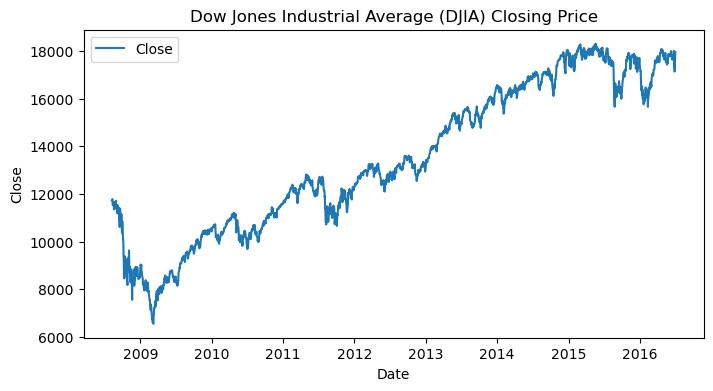

In [ ]:
final_df["Date"] = pd.to_datetime(final_df["Date"])

plt.figure(figsize=(8,4))
plot_data(final_df["Date"], final_df["Close"], title="Dow Jones Industrial Average (DJIA) Closing Price", label="Close")

Text(0.5, 1.0, 'Dow Jones Industrial Average (DJIA) from 2008 to 2016')

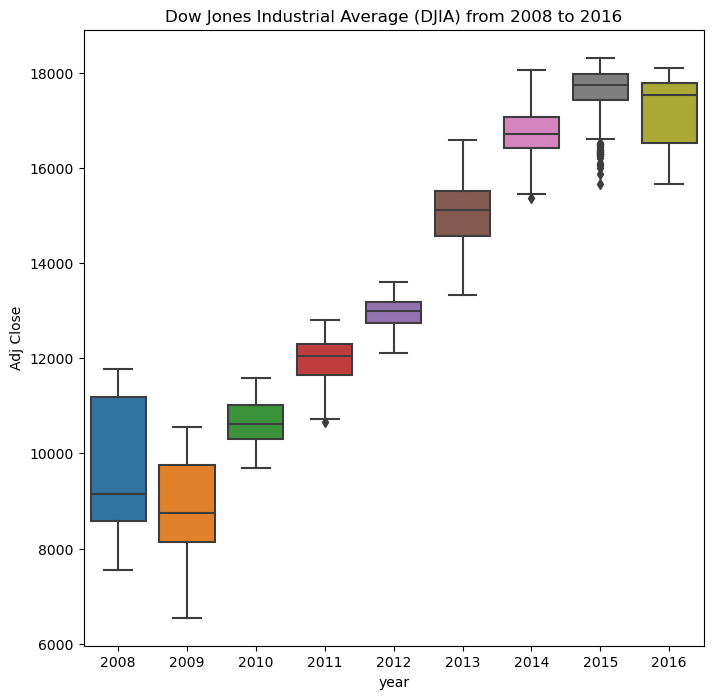

In [ ]:
final_df['year'] = final_df['Date'].dt.year

plt.figure(figsize=(8,8))
sb.boxplot(x="year", y="Adj Close", data=final_df)
plt.title("Dow Jones Industrial Average (DJIA) from 2008 to 2016")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


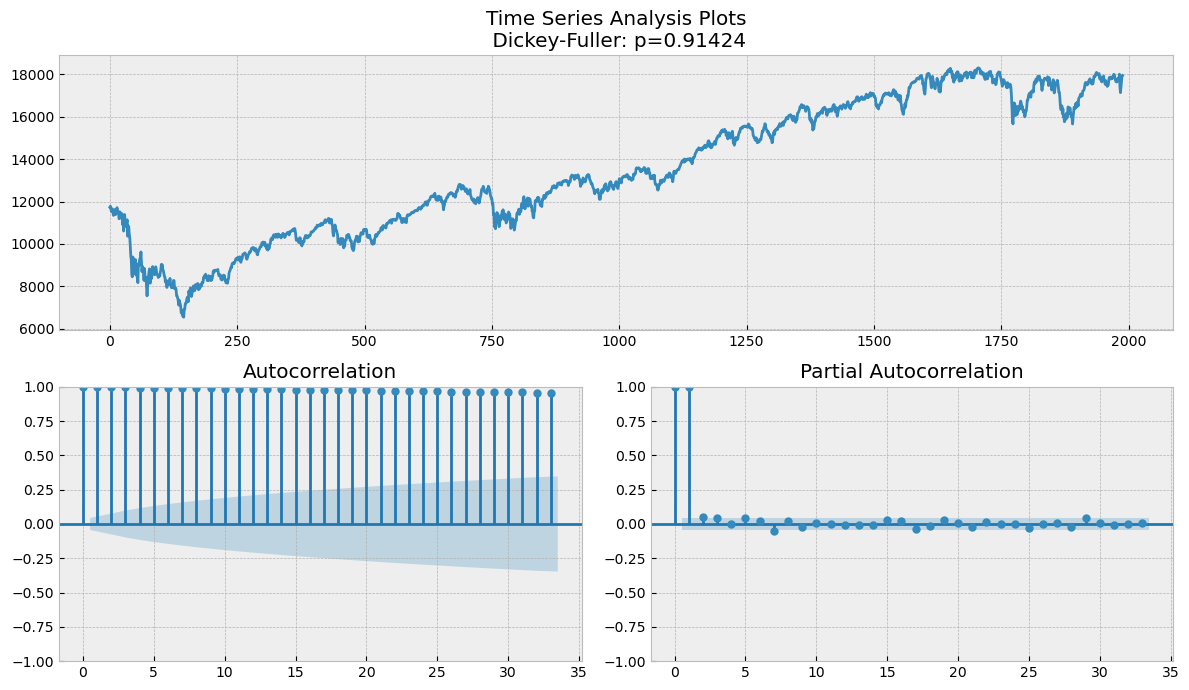

In [ ]:

def stationary_plot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
        
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()
    
stationary_plot(final_df.Close)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


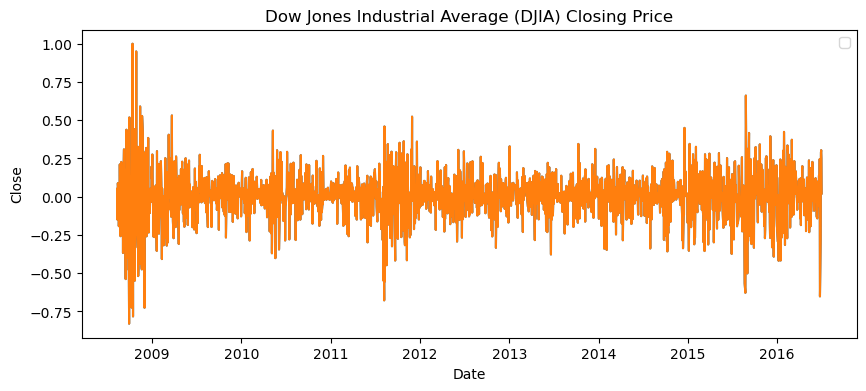

In [ ]:
diff_dist = final_df["Close"] - final_df["Close"].shift(1)
diff_dist = diff_dist / max(diff_dist[1:])
plt.figure(figsize=(10,4))

sb.lineplot(x=final_df["Date"], y=diff_dist)
plot_data(final_df["Date"], diff_dist, title="Dow Jones Industrial Average (DJIA) Closing Price")

### Correlation Between Features

We want to check whether the given features have an interprettable correlation between each other. First, we check on the price dataset.

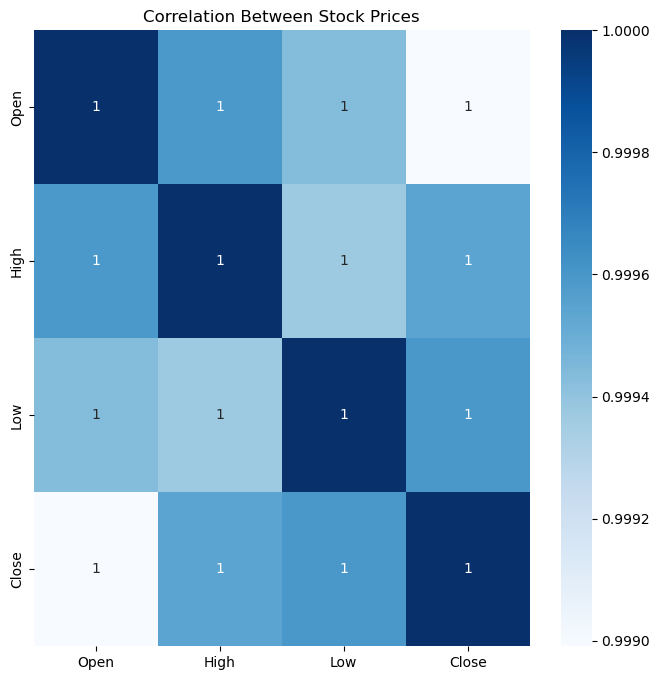

In [ ]:
corr_features = ['Open', 'High', 'Low', 'Close']
plot_corr(final_df, corr_features, "Correlation Between Stock Prices")

We see that all the features have strong correlations with the closing price. Although they are all almost perfectly correlated with the closing price, sometimes, this little difference matters the most. Thus, we will check for correlation between these differences. 

In [ ]:
for col1 in range(1, 4):
    for col2 in range(col1+1, 5):
        name1 = final_df.columns[col1]
        name2 = final_df.columns[col2]
        name = f"{name1}-{name2}"
        
        final_df[name] = abs(final_df[name1] - final_df[name2].shift(1))

final_df.head()

,Date,Open,High,Low,Close,Adj Close,negative_top1,neutral_top1,positive_top1,negative_top2,...,negative_top25,neutral_top25,positive_top25,year,Open-High,Open-Low,Open-Close,High-Low,High-Close,Low-Close
0,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,11734.320312,0.552167,0.437650,0.010183,0.285199,...,0.638448,0.349005,0.012547,2008,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,11782.349609,0.744413,0.247436,0.008151,0.222044,...,0.588637,0.393123,0.018240,2008,30.290039,341.629883,4.650390,479.070313,132.790040,58.790039
2,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,11642.469727,0.591630,0.336137,0.072233,0.186763,...,0.276685,0.685307,0.038007,2008,85.410157,106.169922,0.649414,106.819336,0.000000,180.830078
3,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,11532.959961,0.265182,0.719142,0.015676,0.865281,...,0.387972,0.591107,0.020921,2008,149.540039,31.290039,9.660157,32.260742,8.689454,189.129883
4,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,11615.929688,0.228814,0.665338,0.105847,0.426495,...,0.187739,0.786013,0.026248,2008,101.709961,78.730468,0.889649,264.940429,185.320312,82.070313


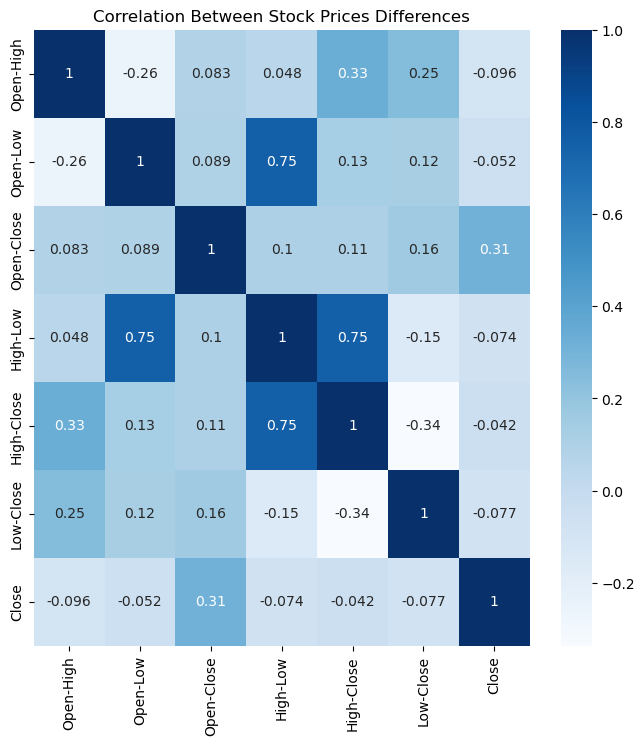

In [ ]:
corr_features = final_df.columns[-6:].to_list()
corr_features.append('Close')
plot_corr(final_df, corr_features, "Correlation Between Stock Prices Differences")

Conclusion: These values have low correlation with each other, the highest one is Open-Close with value 0.31 (which does not give us useful information)

### Visualizing Sentiment Score
Next, we will find the correlation of our sentiment dataset with our closing price

In [ ]:
sentiment_df = pd.read_csv('dataset/sentiment.csv')
sentiment_df = pd.concat([final_df["Date"], sentiment_df], axis=1)
prefixes = ["negative", "neutral", "positive"]

for prefix in prefixes:
    columns_to_average = [f"{prefix}_top{i}" for i in range(1, 26)]

    sentiment_df[f"{prefix}_average"] = sentiment_df[columns_to_average].mean(axis=1)
    sentiment_df[f"{prefix}_min"] = sentiment_df[columns_to_average].min(axis=1)
    sentiment_df[f"{prefix}_max"] = sentiment_df[columns_to_average].max(axis=1)

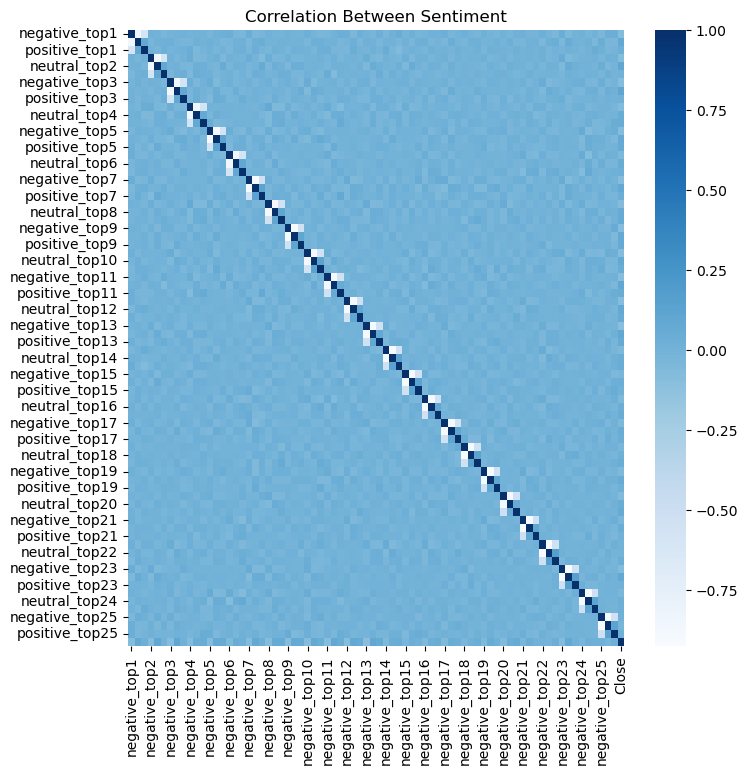

In [ ]:
corr_features = sentiment_df.columns[1:76].tolist()
corr_features.append('Close')
plot_corr(final_df, corr_features, "Correlation Between Sentiment", annot=False)

There are no clear correlation between our closing price and our sentiment scores alone. We suspect that this is because our sentiment scores are still noisy. Thus, we will try to simplify the problem by averaging each category of score, which is negative, positive, neutral.

In [ ]:
proc_sentiment_df = sentiment_df.copy()
proc_sentiment_df = proc_sentiment_df[['Date', 'negative_average', 'positive_average', 'neutral_average', 'negative_min', 'positive_min', 'neutral_min', 'negative_max', 'positive_max', 'neutral_max']]
proc_sentiment_df['Date'] = pd.to_datetime(proc_sentiment_df['Date'])
proc_sentiment_df['Close'] = final_df['Close']
proc_sentiment_df.head()

,Date,negative_average,positive_average,neutral_average,negative_min,positive_min,neutral_min,negative_max,positive_max,neutral_max,Close
0,2008-08-08,0.535359,0.019479,0.445162,0.104257,0.001911,0.031086,0.966567,0.164409,0.775412,11734.320312
1,2008-08-11,0.484244,0.099345,0.416411,0.002169,0.001663,0.027377,0.970770,0.695927,0.896839,11782.349609
2,2008-08-12,0.419876,0.050652,0.529472,0.024746,0.001973,0.050527,0.946747,0.317276,0.886369,11642.469727
3,2008-08-13,0.372418,0.069281,0.558301,0.013053,0.005804,0.128091,0.865281,0.478783,0.916282,11532.959961
4,2008-08-14,0.456842,0.067112,0.476046,0.006578,0.002120,0.076399,0.921481,0.830805,0.899294,11615.929688


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

Text(0.5, 1.0, 'Neutral Sentiment from 2008 to 2016')

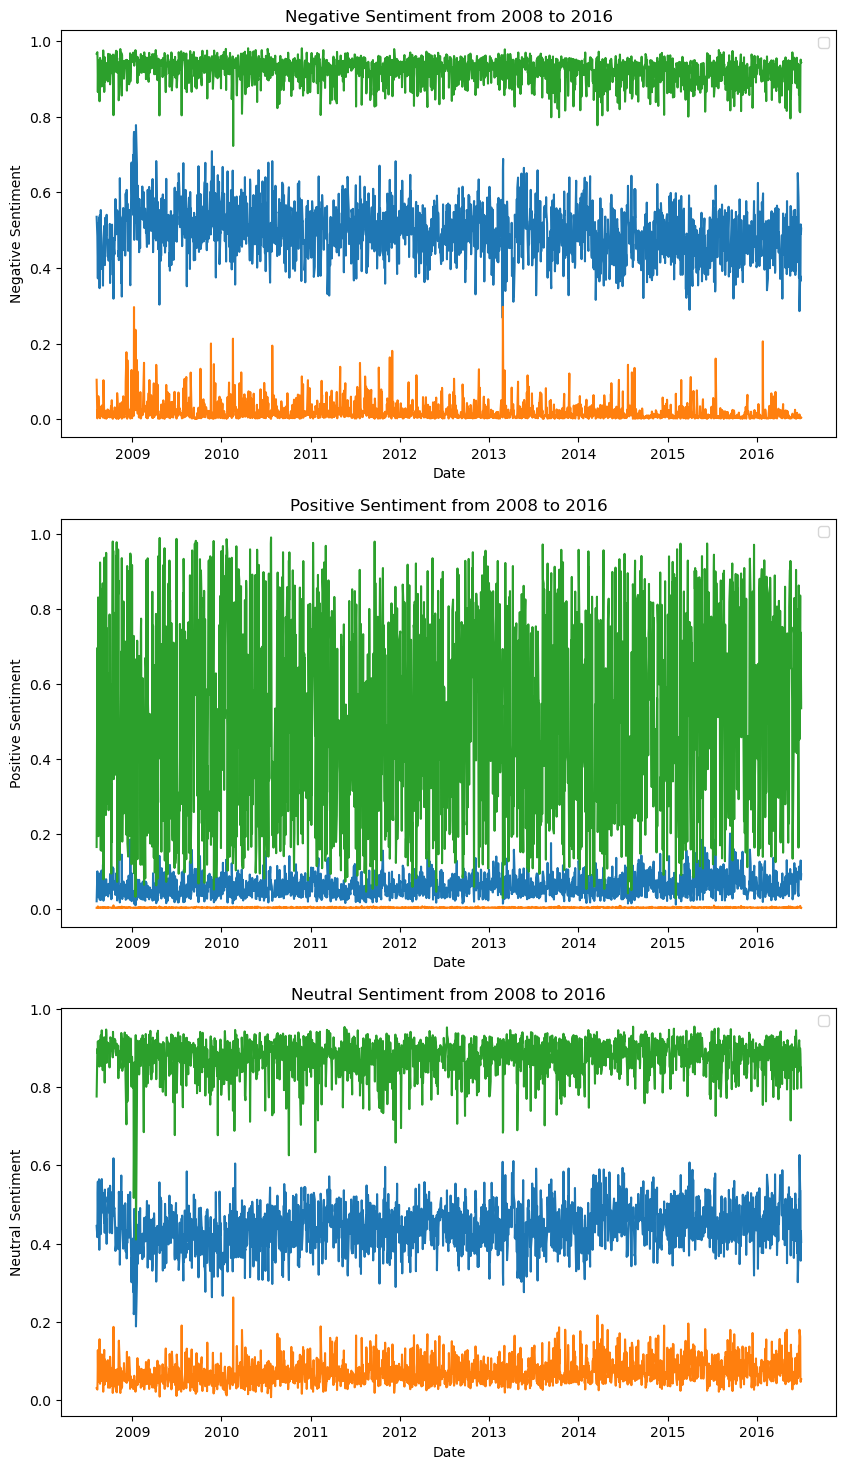

In [ ]:
plt.figure(figsize=(10,18))

plt.subplot(3, 1, 1)
plot_data(proc_sentiment_df["Date"], proc_sentiment_df["negative_average"], title="Negative Sentiment from 2008 to 2016")
plot_data(proc_sentiment_df["Date"], proc_sentiment_df["negative_min"], title="Negative Sentiment from 2008 to 2016")
plot_data(proc_sentiment_df["Date"], proc_sentiment_df["negative_max"], title="Negative Sentiment from 2008 to 2016")
plt.ylabel("Negative Sentiment")
plt.title("Negative Sentiment from 2008 to 2016")

plt.subplot(3, 1, 2)
plot_data(proc_sentiment_df["Date"], proc_sentiment_df["positive_average"], title="Positive Sentiment from 2008 to 2016")
plot_data(proc_sentiment_df["Date"], proc_sentiment_df["positive_min"], title="Positive Sentiment from 2008 to 2016")
plot_data(proc_sentiment_df["Date"], proc_sentiment_df["positive_max"], title="Positive Sentiment from 2008 to 2016")
plt.ylabel("Positive Sentiment")
plt.title("Positive Sentiment from 2008 to 2016")

plt.subplot(3,1,3)
plot_data(proc_sentiment_df["Date"], proc_sentiment_df["neutral_average"], title="Neutral Sentiment from 2008 to 2016")
plot_data(proc_sentiment_df["Date"], proc_sentiment_df["neutral_min"], title="Neutral Sentiment from 2008 to 2016")
plot_data(proc_sentiment_df["Date"], proc_sentiment_df["neutral_max"], title="Neutral Sentiment from 2008 to 2016")
plt.ylabel("Neutral Sentiment")
plt.title("Neutral Sentiment from 2008 to 2016")

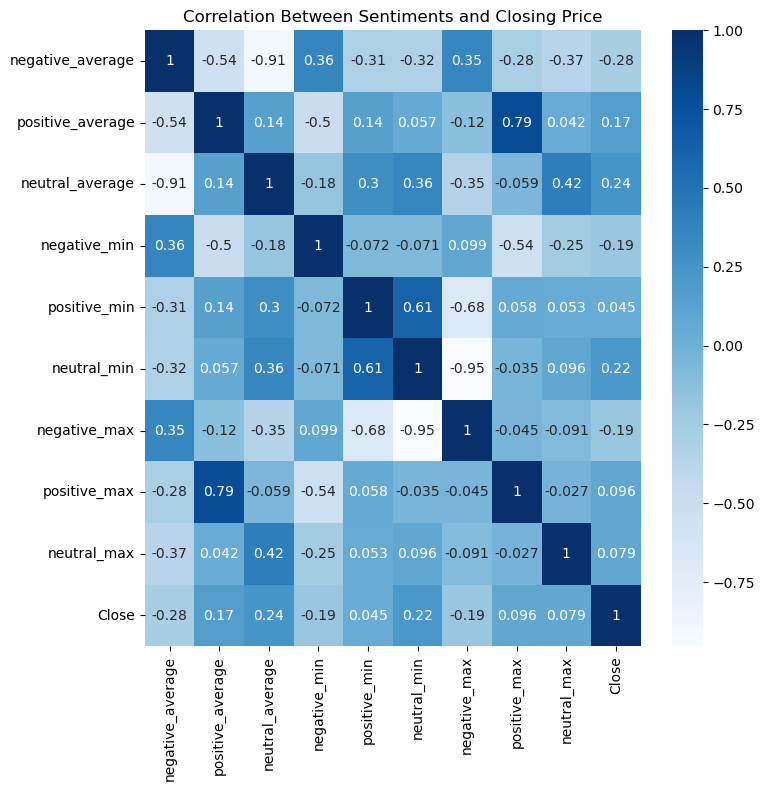

In [ ]:
corr_features = proc_sentiment_df.columns.tolist()[1:]
plot_corr(proc_sentiment_df, corr_features, "Correlation Between Sentiments and Closing Price")

Conclusion: 
- The closing price are weakly correlated with the sentiment score.
- The average value of each category has a higher correlation compared to the min and max.

### Adding More Features

Since all features we have encountered have a relatively low correlation, then we need to create more features that have a higher correlation in order for the model to work well. Note that we do not need to understand what these extra features means, we just want to experiment whether these extra features helps with our prediction. 

Here, we are going to use: 
* `short_window` = 12
* `long_window` = 26
* `signal_window`= 9

In [ ]:
short_window = 12
long_window = 26
signal_window = 9
window_length = 14

#### Exponential Moving Average (EMA)
In simple word, rather than having the same weight to all datas, the formula will add more bias to recent datas and less weight to older datas. This weighing factor is set between 0 and 1, where higher value gives more weight to recent datas. Short EMA and Long EMA only differs on the length of windows used, where the former use a shorter window compared to the latter. Moving averages work quite well in strong trending conditions, thus it may provide us with some good information since our datasets have increasing trend.

In [ ]:
def calculate_ema(df):
    df['ShortEMA'] = df['Close'].ewm(span=short_window, min_periods=1, adjust=False).mean()
    df['LongEMA'] = df['Close'].ewm(span=long_window, min_periods=1, adjust=False).mean()
    df['MACD'] = df['ShortEMA'] - df['LongEMA']
    df['Signal Line'] = df['MACD'].ewm(span=signal_window, min_periods=1, adjust=False).mean()
    return df

final_df = calculate_ema(final_df)

#### Moving Average Convergance / Divergence (MACD) and Signal Line
"The moving average convergence/divergence (MACD, or MAC-D) line is calculated by subtracting the 26-period exponential moving average (EMA) from the 12-period EMA. The signal line is a nine-period EMA of the MACD line." - <span><a href="https://www.investopedia.com/terms/m/macd.asp">Source</a></span>. These technical indicators act as an alert of change in directional trends.

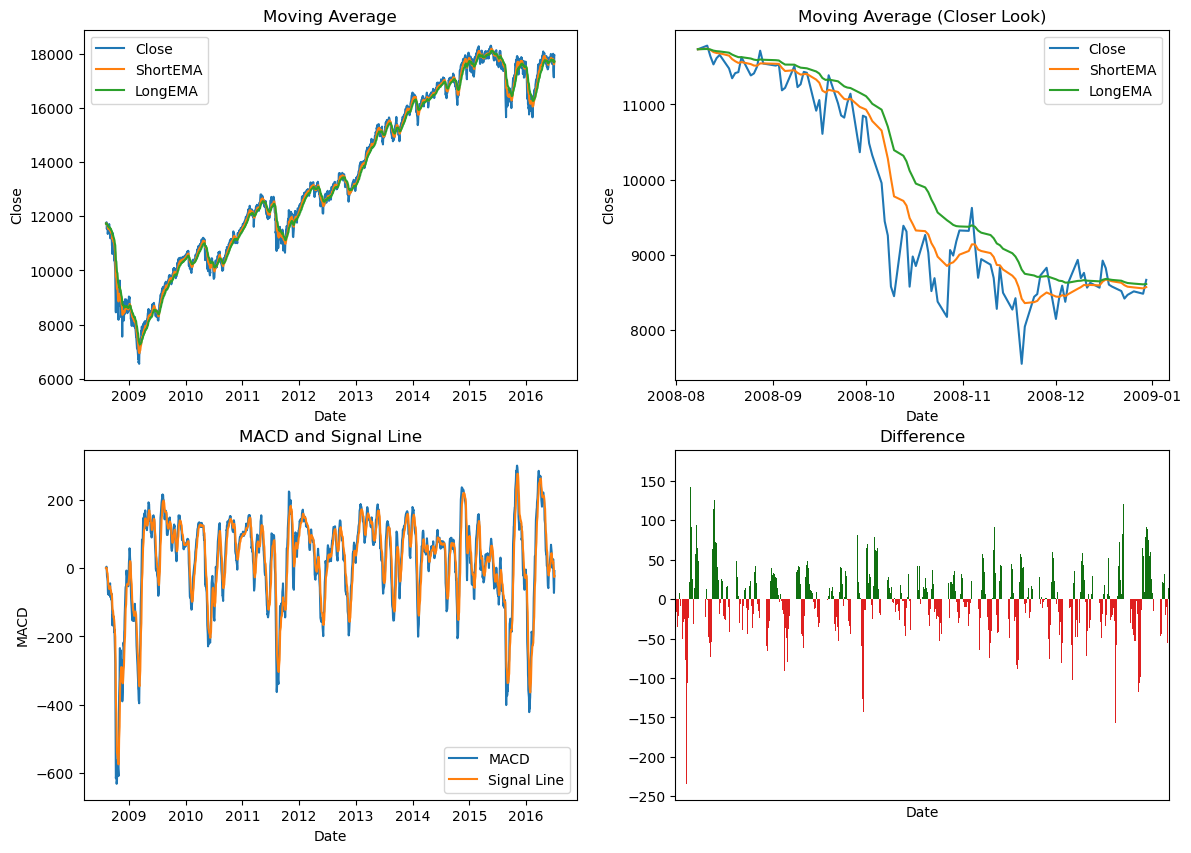

In [ ]:
plt.figure(figsize=(14,10))
## Plotting the closing price and the moving averages
plt.subplot(2,2,1)
plot_data(final_df['Date'], final_df['Close'], label='Close')
plot_data(final_df['Date'], final_df['ShortEMA'], label='ShortEMA')
plot_data(final_df['Date'], final_df['LongEMA'], title='Moving Average', label='LongEMA')

plt.subplot(2,2,2)
plot_data(final_df['Date'], final_df['Close'], 100, label='Close')
plot_data(final_df['Date'], final_df['ShortEMA'], 100, label='ShortEMA')
plot_data(final_df['Date'], final_df['LongEMA'], 100, title='Moving Average (Closer Look)', label='LongEMA')

## Plotting the MACD and the signal line
plt.subplot(2,2,3)
plot_data(final_df['Date'], final_df['MACD'], label="MACD")
plot_data(final_df['Date'], final_df['Signal Line'], title="MACD and Signal Line", label="Signal Line")

plt.subplot(2,2,4)
# plot_data(final_df['Date'], final_df['MACD'], 150, label="MACD")
# plot_data(final_df['Date'], final_df['Signal Line'], 150, title="MACD and Signal Line (Closer Look)", label="Signal Line")
plt.title("Difference")
sb.barplot(x=final_df['Date'], y=final_df['MACD']-final_df['Signal Line'], palette=['r' if final_df['MACD'][i]-final_df['Signal Line'][i] < 0 else 'g' for i in range(len(final_df))]).tick_params(bottom=False, labelbottom=False)

#### Relative Strength Index (RSI)
RSI is an indicator that gives information about the security of the stock's price. It can be calculated by `100 - (100 / (1 + {14-Day Average Gain / 14-Day Average Loss}))`

In [ ]:
def calculate_rsi(df):
    delta = df['Close'].diff(1)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window_length, min_periods=1).mean()
    avg_loss = loss.rolling(window=window_length, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

final_df = calculate_rsi(final_df)

#### Simple Moving Average (SMA)
SMA is another variation of moving average that weights stock prices from the past equally. Simply, the value can be calculated by averaging the stock prices on the last `window_length` days. 

In [ ]:
window_length = 20

def calculate_sma(df):
    df['MA'] = df['Close'].rolling(window=window_length, min_periods=1).mean()
    return df

final_df = calculate_sma(final_df)

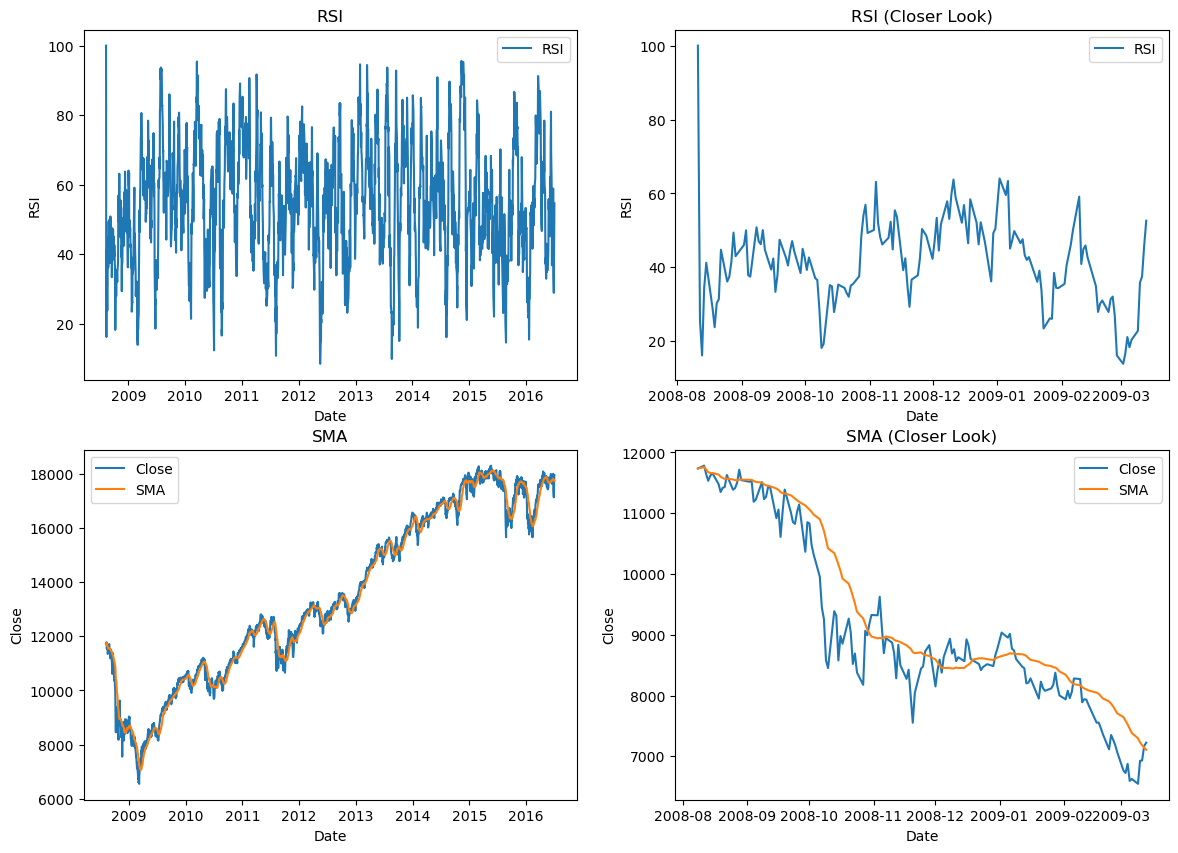

In [ ]:
plt.figure(figsize=(14,10))
## Plotting the closing price and the moving averages
plt.subplot(2,2,1)
plot_data(final_df['Date'], final_df['RSI'], title="RSI", label="RSI")

plt.subplot(2,2,2)
plot_data(final_df['Date'], final_df['RSI'], 150, title="RSI (Closer Look)", label="RSI")

## Plotting the MACD and the signal line
plt.subplot(2,2,3)
plot_data(final_df['Date'], final_df['Close'], label="Close")
plot_data(final_df['Date'], final_df['MA'], title="SMA", label="SMA")

plt.subplot(2,2,4)
plt.title("SMA Closer Look")
plot_data(final_df['Date'], final_df['Close'], 150, label="Close")
plot_data(final_df['Date'], final_df['MA'], 150, title="SMA (Closer Look)", label="SMA")

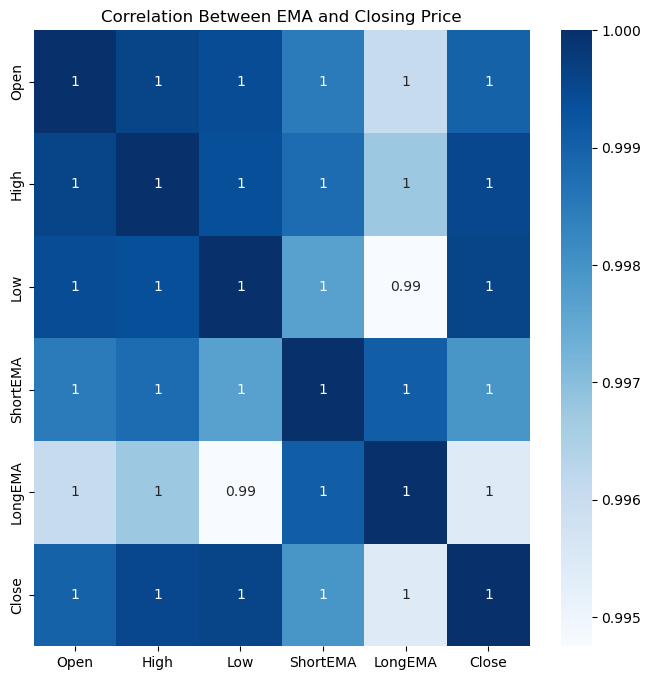

In [ ]:
corr_features = ['Open', 'High', 'Low', 'ShortEMA', 'LongEMA', 'Close']
plot_corr(final_df, corr_features, "Correlation Between EMA and Closing Price")

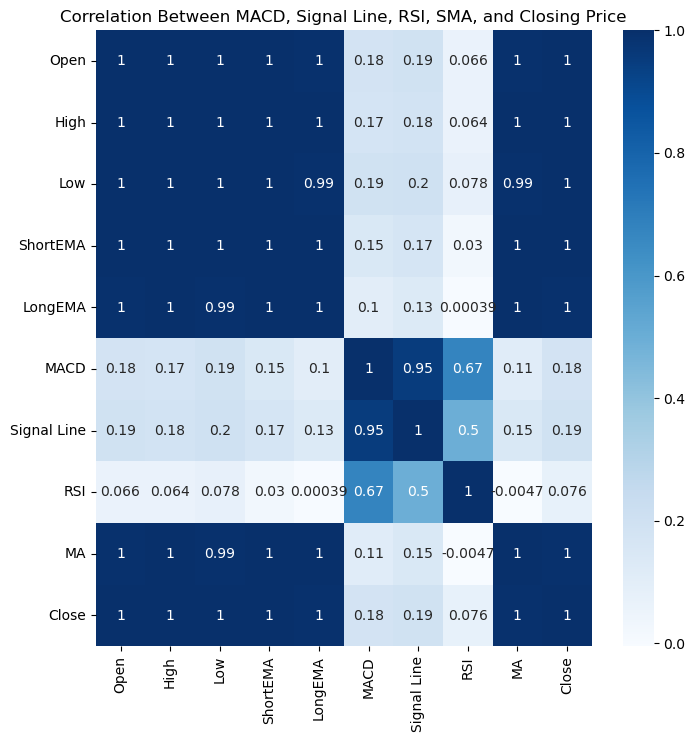

In [ ]:
corr_features = ['Open', 'High', 'Low', 'ShortEMA', 'LongEMA', 'MACD', 'Signal Line', 'RSI', 'MA', 'Close']
plot_corr(final_df, corr_features, "Correlation Between MACD, Signal Line, RSI, SMA, and Closing Price")

### Adding More (and More) Features
As seen from the heat map above, even with adding more technical term such as Moving Average, the results are still not good enough to make a prediction. Let's try to add more advanced technical terms: 

#### Average True Range (ATR)

ATR is an indicator that measures volatility of our stock prices. This can bd calculated by averaging the true ranges of a given window.
True ranges itself is the maximum value of `High - Low` , `High - Close`, and `Low - Close`.

In [ ]:
# ATR calculation
def calculate_atr(df, window=14):
    high_low = df['High'] - df['Low']
    high_close = df['High-Close']
    low_close = df['Low-Close']
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    atr = true_range.rolling(window=window).mean()
    
    # df['ATR'] column represents the Average True Range
    df['ATR'] = atr 
    return df

final_df = calculate_atr(final_df)


#### Stochastic Oscillator

There are 2 values in Stochastic Oscillator, `%K` and `%D`. `%K` can be calculated by `100 * (Close - low_min) / (high_max - low_min)` and `%D` is the 3-Day average of `%K`.
<br>
Where: 
* `low_min` is the lowest price from the beginning of the stock observation until the current day
* `high_max` is the highest price from the beginning of the stock observation until the current day

In [ ]:
# Stochastic Oscillator calculation
def calculate_stochastic_oscillator(df, period=14):
    low_min = df['Low'].rolling(window=period).min()
    high_max = df['High'].rolling(window=period).max()
    
    # df['%K'] and df['%D'] columns represent the Stochastic Oscillator values
    df['%K'] = 100 * ((df['Close'] - low_min) / (high_max - low_min))
    df['%D'] = df['%K'].rolling(window=3).mean()  # 3-day moving average of %K
    return df

final_df = calculate_stochastic_oscillator(final_df)

#### Bollinger Bands

We are only going to use the Upper and Lower value of the Bollinger Bands (i.e we discarded the Middle Band). We can calculate these values by using the formula: 
* `Upper Band` = `window`-Day mean + 2 * `window`-Day std
* `Lower Band` = `window`-Day mean - 2 * `window`-Day std
* `window` = 20

In [ ]:
# Bollinger Bands calculation
def calculate_bollinger_bands(df, window=20, num_std_dev=2):
    rolling_mean = df['Close'].rolling(window=window).mean()
    rolling_std = df['Close'].rolling(window=window).std()
    
    # df['Upper Band'] and df['Lower Band'] columns represent the Bollinger Bands
    df['Upper Band'] = rolling_mean + (num_std_dev * rolling_std)
    df['Lower Band'] = rolling_mean - (num_std_dev * rolling_std)
    return df

final_df = calculate_bollinger_bands(final_df)


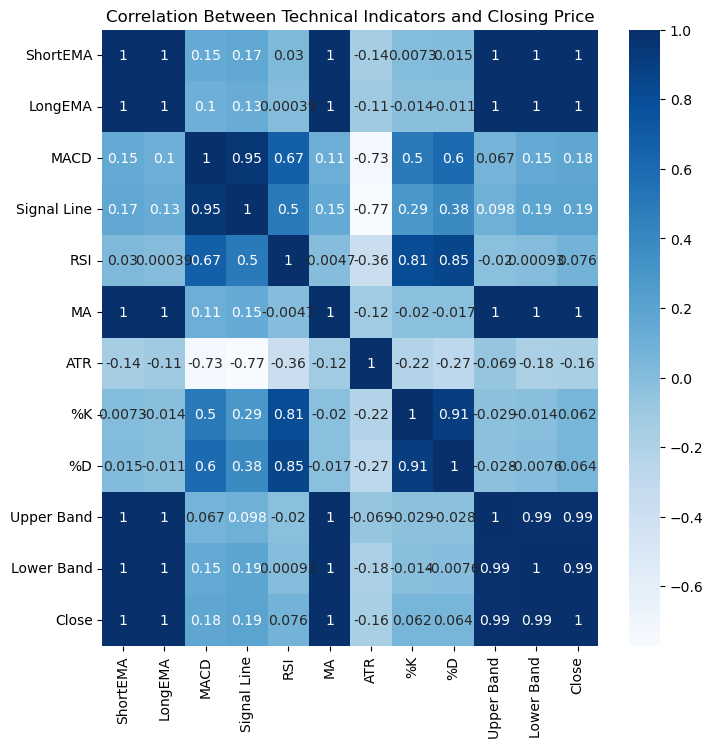

In [ ]:
corr_features = final_df.columns[-11:].tolist()
corr_features.append('Close')
plot_corr(final_df, corr_features, "Correlation Between Technical Indicators and Closing Price")

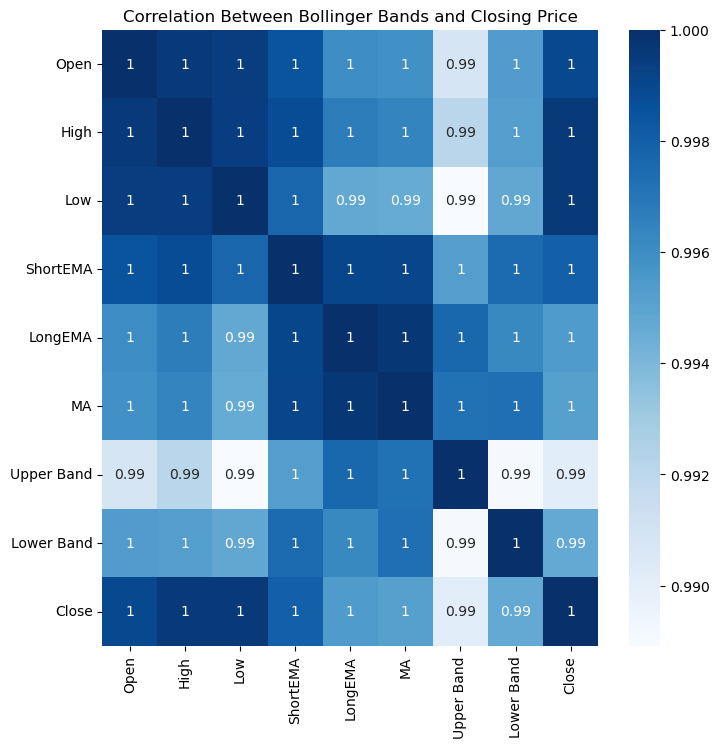

In [ ]:
corr_features = ['Open', 'High', 'Low', 'ShortEMA', 'LongEMA', 'MA', 'Upper Band', 'Lower Band', 'Close']
plot_corr(final_df, corr_features, "Correlation Between Bollinger Bands and Closing Price")

### Conclusion of Exploratory Data Analysis
Again, after all these calculations, we still cannot see any strong linear correlation between all these new features and stock's closing price. With this, we can assume that Linear Models would not be the best fit for this Machine Learning Problem since it will not be able to represent the data. One way to overcome this is by using to add non-linearity to the features (i.e. Sigmoid, tanh, relu activation functions in neural network models).